<a href="https://colab.research.google.com/github/PawanBadak/PDS-Practicals/blob/main/Practical_9(A_74)_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical-9

Name :- Pavan Badak

Roll No. :- A-74

Batch :- SY-(AI&DS)

**Aim** - Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow

**Theory**

A Data Science Pipeline is a systematic and organized process used to extract useful insights and build predictive models from raw data. It combines multiple steps such as data collection, preprocessing, analysis, and modeling into a single workflow. This pipeline ensures that the process is efficient, reproducible, and easy to manage.

The first step in the pipeline is data collection, where data is gathered from various sources like databases, websites, APIs, or CSV files. Once the data is collected, it is often incomplete or inconsistent, so the next step is data cleaning and preprocessing. In this stage, missing values are handled, duplicates are removed, and errors in the dataset are corrected to improve data quality.


**1. What is a Data Science Pipeline? Explain its key stages with examples.**

A Data Science Pipeline is a step-by-step process used to collect, process, analyze, and model data to get useful insights or predictions. It ensures that the workflow is organized, repeatable, and efficient.

Key Stages of a Data Science Pipeline:

Data Collection
Gathering data from sources like databases, APIs, CSV files, etc.
Example: Collecting customer data from an e-commerce website.

Data Cleaning (Preprocessing)
Handling missing values, removing duplicates, correcting errors.
Example: Filling missing age values with the average age.
Exploratory Data Analysis (EDA)

Understanding data using graphs and statistics.
Example: Plotting sales trends using bar charts.

Feature Engineering
Creating new useful features from existing data.
Example: Creating “total purchase amount” from individual items.

Model Building
Training machine learning models on the dataset.
Example: Using a regression model to predict house prices.






**2. What is Exploratory Data Analysis (EDA)? How do univariate and bivariate analyses help in understanding the dataset?**

Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize their main characteristics using statistical methods and visualizations.

Types of Analysis:
a) Univariate Analysis
Analyzes one variable at a time.
Helps understand distribution, central tendency, and spread.

Examples:

Histogram of age
Mean, median, mode calculation

Use:

Detect outliers
Understand data distribution
b) Bivariate Analysis
Analyzes relationship between two variables.

Examples:

Scatter plot between salary and experience
Correlation matrix

Use:

Identify relationships or patterns
Understand how one variable affects another

**3. Differentiate between Label Encoding and One-Hot Encoding. When should each be used?**

Feature	Label Encoding	One-Hot Encoding
Definition	Converts categories into numeric labels	Converts categories into binary columns
Example	Red=0, Blue=1, Green=2	Red=[1,0,0], Blue=[0,1,0]
Output	Single column	Multiple columns
Relationship	Implies order (may mislead model)	No order is implied
Use Case	When categories have order (ordinal data)	When categories are nominal (no order)

**4. Why is feature scaling required? Compare normalization and standardization.**

Feature scaling is used to bring all features to a similar range so that no feature dominates others in model training.

Why it is required:
Improves model performance
Speeds up convergence in algorithms
Important for distance-based models (like KNN, SVM)
Normalization vs Standardization:
Normalization (Min-Max Scaling)

**5. What is Feature Engineering? Explain how creating new features can improve model performance.**

Feature Engineering is the process of creating new input features from existing data to improve the performance of machine learning models.

Why it is important:
Helps models learn better patterns
Increases accuracy
Makes hidden relationships visible
Examples:
Extracting day, month, year from a date column
Creating BMI from height and weight
Combining features like “price × quantity” to get total cost
How it improves performance:
Provides more meaningful input to the model
Reduces noise
Enhances predictive power

**Part-1**


Initial Dataset Preview:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
--

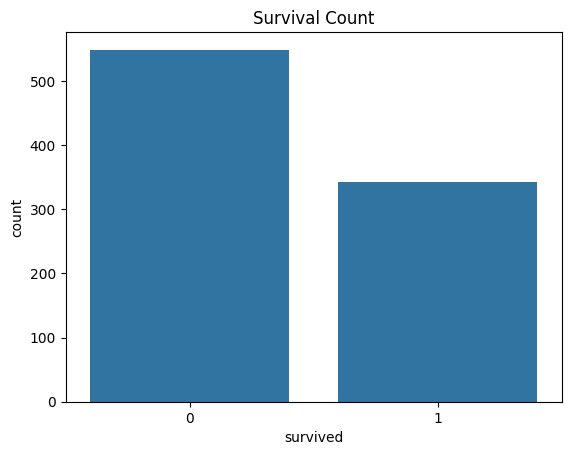

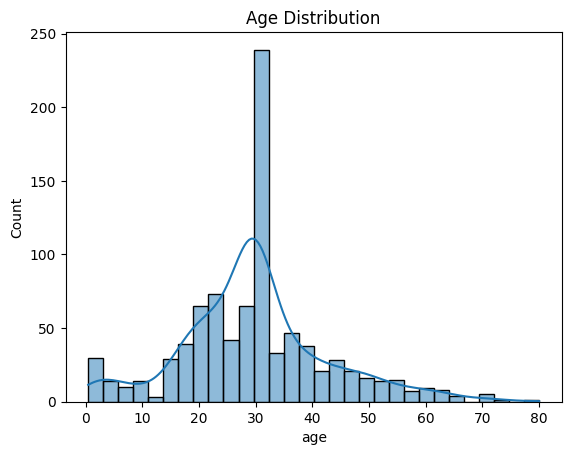

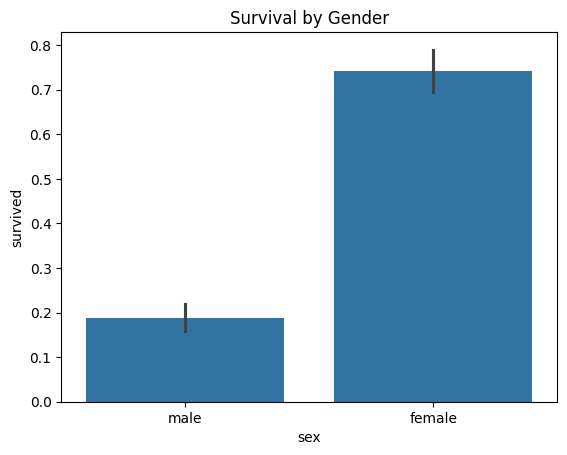

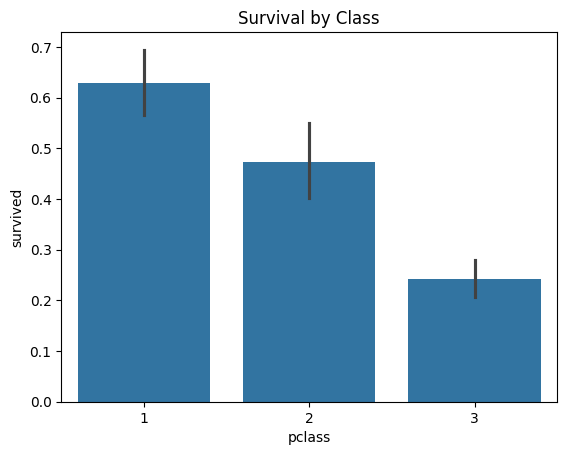


--- Logistic Regression Results ---
Accuracy: 0.8268156424581006
Confusion Matrix:
 [[101   9]
 [ 22  47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       110
           1       0.84      0.68      0.75        69

    accuracy                           0.83       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179


--- Decision Tree Results ---
Accuracy: 0.7541899441340782
Confusion Matrix:
 [[95 15]
 [29 40]]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# FINAL EXPERIMENT: COMPLETE DATA SCIENCE PIPELINE
# Dataset: Titanic (Seaborn)
# ============================================================

# -------------------- STEP 1: IMPORT LIBRARIES --------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


# -------------------- STEP 2: LOAD DATA --------------------
df = sns.load_dataset('titanic')

print("\nInitial Dataset Preview:\n", df.head())
print("\nDataset Shape:", df.shape)


# -------------------- STEP 3: DATA UNDERSTANDING --------------------
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())


# -------------------- STEP 4: DATA CLEANING --------------------
# Drop irrelevant columns
df.drop(['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'], axis=1, inplace=True)

# Handle missing values
age_imputer = SimpleImputer(strategy='mean')
df['age'] = age_imputer.fit_transform(df[['age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
df['embarked'] = embarked_imputer.fit_transform(df[['embarked']]).ravel()

# Drop remaining missing target rows (if any)
df.dropna(subset=['survived'], inplace=True)


# -------------------- STEP 5: EXPLORATORY DATA ANALYSIS --------------------
# Univariate Analysis
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Bivariate Analysis
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival by Gender")
plt.show()

sns.barplot(x='pclass', y='survived', data=df)
plt.title("Survival by Class")
plt.show()


# -------------------- STEP 6: FEATURE ENGINEERING --------------------
# Create new feature
df['family_size'] = df['sibsp'] + df['parch']

# Age groups
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 12, 18, 40, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])


# -------------------- STEP 7: ENCODING --------------------
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

# One-hot encoding
df = pd.get_dummies(df, columns=['embarked', 'age_group'], drop_first=True)


# -------------------- STEP 8: FEATURE SCALING --------------------
scaler = StandardScaler()
df[['age', 'fare', 'family_size']] = scaler.fit_transform(df[['age', 'fare', 'family_size']])


# -------------------- STEP 9: DEFINE FEATURES & TARGET --------------------
X = df.drop('survived', axis=1)
y = df['survived']


# -------------------- STEP 10: TRAIN-TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------- STEP 11: MODEL BUILDING --------------------
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


# -------------------- STEP 12: EVALUATION --------------------
print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


# -------------------- STEP 13: CROSS-VALIDATION --------------------
cv_scores = cross_val_score(lr_model, X, y, cv=5)
print("\nCross-validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


# -------------------- STEP 14: MODEL COMPARISON --------------------
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("\nModel Comparison:")
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

best_model = "Logistic Regression" if lr_acc > dt_acc else "Decision Tree"
print("Best Model:", best_model)


# -------------------- STEP 15: FINAL PREDICTION --------------------
sample = X_test.iloc[0:1]
prediction = lr_model.predict(sample)

print("\nSample Prediction:", prediction)
print("Actual Value:", y_test.iloc[0])

import matplotlib.pyplot as plt
plt.show()

# ============================================================
# END OF PIPELINE
# ============================================================

**Conclusion**

In this practical, we successfully built a simple Data Science pipeline by integrating various steps such as data preprocessing, exploratory data analysis, feature engineering, encoding, and feature scaling. We understood how raw data is cleaned and transformed into a suitable format for machine learning models. Through EDA, we analyzed patterns and relationships in the dataset, which helped in better decision-making.

We also learned the importance of encoding categorical data and scaling features to improve model performance. Overall, this practical helped us understand the complete workflow of a data science project, making it easier to handle real-world datasets and build efficient predictive models.